In [0]:
from pyspark.sql.functions import *
from pyspark.sql.window import *
import matplotlib.pyplot as plt
import seaborn as sns

# Leitura do Dataset

In [0]:
df_pm = spark.table("pos_fiap.datathon.passos_magicos")

# Perguntas

## Perguntas para ser respondidas na análise

1. Adequação do nível (IAN)\
Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui aolongo do ano?\
(Ex.: quantos alunos estão moderadamente ou severamente defasados?)
2. Desempenho acadêmico (IDA)\
O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?
3. Engajamento nas atividades (IEG)\
O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?
4. Autoavaliação (IAA)\
As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?
5. Aspectos psicossociais (IPS)\
Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?
6. Aspectos psicopedagógicos (IPP)\
As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?
7. Ponto de virada (IPV)\
Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?
8. Multidimensionalidade dos indicadores\
Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?
---
9. ~~Previsão de risco com Machine Learning~~ `Será respondida no notebook 3: Modelo`\
~~Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.~~
---
10. Efetividade do programa\
Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?
11. Insights e criatividade\
Você pode adicionar mais insights e pontos de vista não abordados nas perguntas, utilize a criatividade e a análise dos dados para trazer sugestões para a Passos Mágicos.

## 1. Adequação do nível (IAN)

Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?\
Ex.: quantos alunos estão moderadamente ou severamente defasados?

In [0]:
df_pm.groupBy("ano", "defasagem", "ian", "ian_defasagem").count().display()

ano,defasagem,ian,ian_defasagem,count
2024-01-01,-2,5.0000,Moderada,90
2024-01-01,3,10.0000,Em fase,2
2024-01-01,2,10.0000,Em fase,16
2024-01-01,-1,5.0000,Moderada,441
2024-01-01,-3,2.5000,Severa,3
2024-01-01,0,10.0000,Em fase,485
2024-01-01,1,10.0000,Em fase,119
2023-01-01,0,10.0000,Em fase,420
2023-01-01,-1,5.0000,Moderada,408
2023-01-01,-4,2.5000,Severa,1


Databricks visualization. Run in Databricks to view.

## 2. Desempenho acadêmico (IDA)
O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

In [0]:
df_pm.groupBy("ano").agg(round(avg("ida"), 2).alias("ida")).display()

ano,ida
2024-01-01,6.36
2023-01-01,6.66
2022-01-01,6.09


Databricks visualization. Run in Databricks to view.

In [0]:
df_pm.filter(col("ida").isNotNull()).groupBy("ano", "fase").agg(round(avg("ida"), 2).alias("ida")).display()

ano,fase,ida
2024-01-01,4,5.88
2024-01-01,1,6.81
2024-01-01,ALFA,7.34
2024-01-01,5,6.46
2024-01-01,2,6.28
2024-01-01,7,5.82
2024-01-01,3,5.35
2024-01-01,6,7.23
2024-01-01,8,8.00
2023-01-01,4,6.00


Databricks visualization. Run in Databricks to view.

## 3. Engajamento nas atividades (IEG)
O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

In [0]:
df_pm.select("ano", "ieg", "ida", "ipv").display()

ano,ieg,ida,ipv
2024-01-01,8.7000,8.0000,5.4000
2024-01-01,9.3000,8.0000,7.1000
2024-01-01,9.1000,8.0000,7.0000
2024-01-01,9.8000,7.0000,7.2000
2024-01-01,4.2000,7.5000,4.2000
2024-01-01,10.0000,8.3000,7.8000
2024-01-01,10.0000,10.0000,9.7000
2024-01-01,8.6000,7.5000,6.3000
2024-01-01,9.5000,8.5000,8.3000
2024-01-01,9.5000,9.3000,7.8000


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

In [0]:
# print(df_pm.stat.corr("ieg", "ida"))
# df_pm.select(corr("ieg", "ida")).show()
df_pm.select(round(corr("ieg", "ida"), 2).alias("correlacao")).display()

correlacao
0.54


In [0]:
df_pm.select("ano", "ieg", "ida", "ipv").display()

ano,ieg,ida,ipv
2024-01-01,8.7000,8.0000,5.4000
2024-01-01,9.3000,8.0000,7.1000
2024-01-01,9.1000,8.0000,7.0000
2024-01-01,9.8000,7.0000,7.2000
2024-01-01,4.2000,7.5000,4.2000
2024-01-01,10.0000,8.3000,7.8000
2024-01-01,10.0000,10.0000,9.7000
2024-01-01,8.6000,7.5000,6.3000
2024-01-01,9.5000,8.5000,8.3000
2024-01-01,9.5000,9.3000,7.8000


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

In [0]:
# print(df_pm.stat.corr("ieg", "ipv"))
# df_pm.select(corr("ieg", "ipv")).show()
df_pm.select(round(corr("ieg", "ipv"), 2).alias("correlacao")).display()

correlacao
0.56


## 4. Autoavaliação (IAA)
As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

In [0]:
df_pm.select("ano", "iaa", "ida", "ieg").display()

ano,iaa,ida,ieg
2024-01-01,10.0000,8.0000,8.7000
2024-01-01,10.0000,8.0000,9.3000
2024-01-01,10.0000,8.0000,9.1000
2024-01-01,8.0000,7.0000,9.8000
2024-01-01,9.0000,7.5000,4.2000
2024-01-01,10.0000,8.3000,10.0000
2024-01-01,9.5000,10.0000,10.0000
2024-01-01,9.0000,7.5000,8.6000
2024-01-01,10.0000,8.5000,9.5000
2024-01-01,7.9000,9.3000,9.5000


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

In [0]:
# df_pm.select(corr("iaa", "ida")).show()
df_pm.select(round(corr("iaa", "ida"), 2).alias("correlacao")).display()

correlacao
0.12


In [0]:
df_pm.select("ano", "iaa", "ida", "ieg").display()

ano,iaa,ida,ieg
2024-01-01,10.0000,8.0000,8.7000
2024-01-01,10.0000,8.0000,9.3000
2024-01-01,10.0000,8.0000,9.1000
2024-01-01,8.0000,7.0000,9.8000
2024-01-01,9.0000,7.5000,4.2000
2024-01-01,10.0000,8.3000,10.0000
2024-01-01,9.5000,10.0000,10.0000
2024-01-01,9.0000,7.5000,8.6000
2024-01-01,10.0000,8.5000,9.5000
2024-01-01,7.9000,9.3000,9.5000


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

In [0]:
# df_pm.select(corr("iaa", "ieg")).show()
df_pm.select(round(corr("iaa", "ieg"), 2).alias("correlacao")).display()

correlacao
0.13


## 5. Aspectos psicossociais (IPS)
Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

In [0]:
df_pm.select("ano", "ips", "ida", "ieg").display()

ano,ips,ida,ieg
2024-01-01,6.3000,8.0000,8.7000
2024-01-01,3.8000,8.0000,9.3000
2024-01-01,3.8000,8.0000,9.1000
2024-01-01,3.8000,7.0000,9.8000
2024-01-01,3.8000,7.5000,4.2000
2024-01-01,6.3000,8.3000,10.0000
2024-01-01,7.5000,10.0000,10.0000
2024-01-01,7.5000,7.5000,8.6000
2024-01-01,6.3000,8.5000,9.5000
2024-01-01,6.3000,9.3000,9.5000


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

In [0]:
df_pm.select("ano", "ips", "ida", "ieg").display()

ano,ips,ida,ieg
2024-01-01,6.3000,8.0000,8.7000
2024-01-01,3.8000,8.0000,9.3000
2024-01-01,3.8000,8.0000,9.1000
2024-01-01,3.8000,7.0000,9.8000
2024-01-01,3.8000,7.5000,4.2000
2024-01-01,6.3000,8.3000,10.0000
2024-01-01,7.5000,10.0000,10.0000
2024-01-01,7.5000,7.5000,8.6000
2024-01-01,6.3000,8.5000,9.5000
2024-01-01,6.3000,9.3000,9.5000


Databricks visualization. Run in Databricks to view.

Databricks visualization. Run in Databricks to view.

In [0]:
(
    df_pm
    .groupBy("ano")
    .agg(
        round(avg("ips"), 2).alias("ips")
        ,round(avg("ida"), 2).alias("ida")
    )
).display()

ano,ips,ida
2024-01-01,6.83,6.36
2023-01-01,5.12,6.66
2022-01-01,6.91,6.09


Databricks visualization. Run in Databricks to view.

In [0]:
# df_pm.select(corr("ips", "ida")).show()
df_pm.select(round(corr("ips", "ida"), 2).alias("correlacao")).display()

correlacao
0.02


In [0]:
(
    df_pm
    .groupBy("ano")
    .agg(
        round(avg("ips"), 2).alias("ips")
        ,round(avg("ieg"), 2).alias("ieg")
    )
).display()

ano,ips,ieg
2024-01-01,6.83,7.37
2023-01-01,5.12,8.70
2022-01-01,6.91,7.89


Databricks visualization. Run in Databricks to view.

In [0]:
# df_pm.select(corr("ips", "ieg")).show()
df_pm.select(round(corr("ips", "ieg"), 2).alias("correlacao")).display()

correlacao
-0.05


## 6. Aspectos psicopedagógicos (IPP)
As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

In [0]:
df_pm.groupBy("ano", "ian", "ian_defasagem").agg(round(avg("ipp"), 2).alias("ipp")).display()

ano,ian,ian_defasagem,ipp
2024-01-01,2.5000,Severa,7.27
2024-01-01,10.0000,Em fase,7.69
2024-01-01,5.0000,Moderada,7.42
2023-01-01,10.0000,Em fase,7.67
2023-01-01,5.0000,Moderada,7.50
2023-01-01,2.5000,Severa,6.96
2022-01-01,10.0000,Em fase,null
2022-01-01,5.0000,Moderada,null
2022-01-01,2.5000,Severa,null


Databricks visualization. Run in Databricks to view.

In [0]:
df_pm.filter("ano <> '2022-01-01'").select("ano", "ian", "ian_defasagem", "ipp").display()

ano,ian,ian_defasagem,ipp
2024-01-01,10.0000,Em fase,5.6000
2024-01-01,10.0000,Em fase,7.5000
2024-01-01,10.0000,Em fase,7.5000
2024-01-01,5.0000,Moderada,6.9000
2024-01-01,5.0000,Moderada,5.0000
2024-01-01,5.0000,Moderada,7.5000
2024-01-01,5.0000,Moderada,8.1000
2024-01-01,5.0000,Moderada,7.2000
2024-01-01,5.0000,Moderada,7.5000
2024-01-01,5.0000,Moderada,7.5000


Databricks visualization. Run in Databricks to view.

## 7. Ponto de virada (IPV)
Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

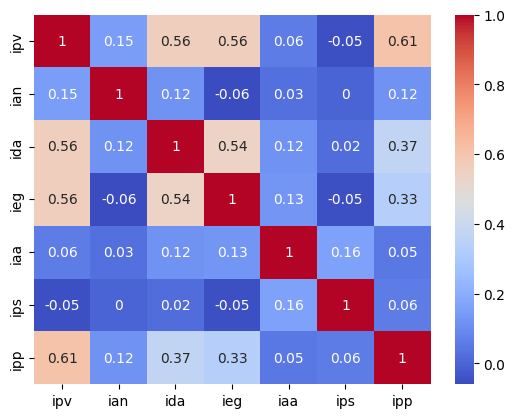

In [0]:
pandas_df = df_pm.select("ipv", "ian", "ida", "ieg", "iaa", "ips", "ipp").toPandas()

matriz_corr = pandas_df.corr().round(2)

# Visualizando com Seaborn
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm')
plt.show()

In [0]:
matriz_correlacao = pandas_df.corr()

correlacao_resultado = matriz_correlacao['ipv']

display(correlacao_resultado)

ipv    1.000000
ian    0.148855
ida    0.556258
ieg    0.558292
iaa    0.062828
ips   -0.049144
ipp    0.606367
Name: ipv, dtype: float64

In [0]:
df_pm.select("ano", "ipv", "ida", "ieg", "ipp").display()

ano,ipv,ida,ieg,ipp
2024-01-01,5.4000,8.0000,8.7000,5.6000
2024-01-01,7.1000,8.0000,9.3000,7.5000
2024-01-01,7.0000,8.0000,9.1000,7.5000
2024-01-01,7.2000,7.0000,9.8000,6.9000
2024-01-01,4.2000,7.5000,4.2000,5.0000
2024-01-01,7.8000,8.3000,10.0000,7.5000
2024-01-01,9.7000,10.0000,10.0000,8.1000
2024-01-01,6.3000,7.5000,8.6000,7.2000
2024-01-01,8.3000,8.5000,9.5000,7.5000
2024-01-01,7.8000,9.3000,9.5000,7.5000


Databricks visualization. Run in Databricks to view.

## 8. Multidimensionalidade dos indicadores
Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

| fase | peso | kpis
|---|---|---|
| 0-7 | 1 | ian, iaa, ips, ipp
| 0-7 | 2 | ida, ieg, ipv
| 8 | 1 | ian, iaa
| 8 | 2 | ieg, ips
| 8 | 4 | ida

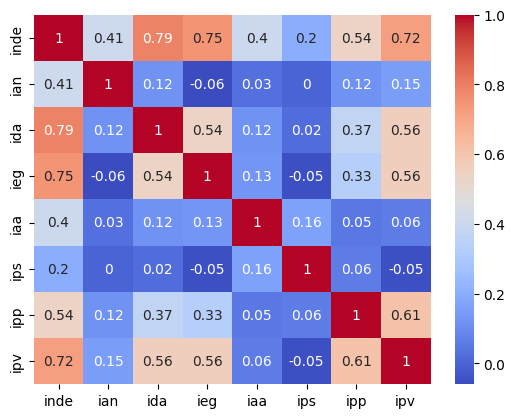

In [0]:
pandas_df = df_pm.select("inde", "ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv").toPandas()

matriz_corr = pandas_df.corr().round(2)

# Visualizando com Seaborn
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm')
plt.show()

## 9. Previsão de risco com Machine Learning
Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.

> Está no notebook 3: Modelo

## 10. Efetividade do programa
Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

In [0]:
df_pm.filter(col("pedra").isNotNull()).groupBy("ano", "pedra").count().display()

ano,pedra,count
2024-01-01,Quartzo,112
2024-01-01,Ágata,225
2024-01-01,Topázio,326
2024-01-01,Ametista,391
2023-01-01,Ágata,246
2023-01-01,Quartzo,72
2023-01-01,Ametista,381
2023-01-01,Topázio,232
2022-01-01,Ágata,250
2022-01-01,Quartzo,132


Databricks visualization. Run in Databricks to view.

## 11. Insights e criatividade

A sugestão é um indicador de nível de suporte (INS), classificando o nível de acompanhamento que o aluno precisa receber:

| Nível | INS | Critérios |
| :---: | :--- | :--- |
| **1** | **Autonomia** | • Aluno veterano (mais de 1 ano no programa), adiantado em pelo menos 1 ano e com alto desempenho (maior do que 8) |
| **2** | **Leve** | • Aluno veterano (mais de 1 ano no programa), e sem defasagem ou adiantado |
| **3** | **Moderado** | • Aluno veterano (mais de 1 ano no programa), mas com defasagem de 1 ano |
| **4** | **Intenso** | • Aluno novo (primeiro ano no programa), ou aluno com defasagem de 2 anos |
| **5** | **Crítico** | • Aluno com defasagem de 3 anos ou mais |


In [0]:
(
    df_pm
    .select("Ano", "Ano_ingresso", "Defasagem", "IDA", "RA")
    .fillna(0)
    .withColumn("tempo_programa", months_between("Ano", concat("Ano_ingresso", lit("-01-01"))) /12)
    .withColumn("nivel_suporte",
        when(col("defasagem") <= -3, 5)
        .when((col("tempo_programa") == 0) | (col("defasagem") == -2), 4)
        .when((col("tempo_programa") > 0) & (col("defasagem") == -1), 3)
        .when((col("tempo_programa") > 0) & (col("defasagem") >= 1) & (col("IDA") >= 8), 1)
        .when((col("tempo_programa") > 0) & (col("defasagem") >= 0), 2)
    .otherwise(None)
    )
).display()

Ano,Ano_ingresso,Defasagem,IDA,RA,tempo_programa,nivel_suporte
2024-01-01,2024,0,8.0000,RA-1275,0.0,4
2024-01-01,2024,0,8.0000,RA-1276,0.0,4
2024-01-01,2024,0,8.0000,RA-1277,0.0,4
2024-01-01,2023,-1,7.0000,RA-868,1.0,3
2024-01-01,2024,-1,7.5000,RA-1278,0.0,4
2024-01-01,2024,-1,8.3000,RA-1279,0.0,4
2024-01-01,2023,-1,10.0000,RA-861,1.0,3
2024-01-01,2023,-2,7.5000,RA-862,1.0,4
2024-01-01,2024,-1,8.5000,RA-1280,0.0,4
2024-01-01,2024,-1,9.3000,RA-1281,0.0,4


Databricks visualization. Run in Databricks to view.